In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from time import time

import PyESRSTM
from PyESRSTM import units

## Spin System

We now need to define the spin on each site, as well as its magnetic field and gyromagnetic field. We add exchange enteractions using optional `Jexch` parameater.

In [2]:
eps = -30
U = 100
Bext = np.array([0.1,  0.,  0.3])
Jexch = np.array([3.,3.,3.])
dot = PyESRSTM.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch,1,0], ])

Hermiticity check passed!
Hermiticity check passed!


In [3]:
print(dot)

idx 	Occup 	Energy [meV] 	Spin central 	Spin total
				 x,  y,  z 	 x,  y,  z
0	1 	-30.033507190 	-0.2 -0.0 -0.5 	-0.3 -0.0 -0.9
1	1 	-30.009305252 	0.0 0.0 -0.0 	0.0 0.0 0.0
2	1 	-29.996898249 	0.0 0.0 0.0 	0.0 0.0 -0.0
3	1 	-29.960289308 	0.2 0.0 0.5 	0.3 0.0 0.9
4	0 	-0.018304470 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
5	0 	0.018304470 	0.0 0.0 0.0 	0.2 0.0 0.5
6	2 	39.981695530 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
7	2 	40.018304470 	0.0 0.0 0.0 	0.2 0.0 0.5


In [4]:
print('Number of spins:',dot.Nspin)
print('Number of states:',dot.Nstate)
print('Occupancy:',dot.Occupancy)
print('Energies [meV]:', np.round(dot.Energies*units.Hartree,3))
print('Theta [deg]: ', np.round(dot.theta/np.pi*180, 3))
print()

print('Spins states')
print('state, spin site,  <Sx>, <Sy>,  <Sz>')
print(np.round(dot.CalcAllSpin(),3))

Number of spins: 2
Number of states: 8
Occupancy: [1 1 1 1 0 0 2 2]
Energies [meV]: [-3.0034e+01 -3.0009e+01 -2.9997e+01 -2.9960e+01 -1.8000e-02  1.8000e-02
  3.9982e+01  4.0018e+01]
Theta [deg]:  18.435

Spins states
state, spin site,  <Sx>, <Sy>,  <Sz>
[[[ 1.     1.    -0.158 -0.    -0.474]
  [ 1.     2.    -0.158 -0.    -0.474]]

 [[ 2.     1.     0.     0.    -0.   ]
  [ 2.     2.     0.     0.     0.   ]]

 [[ 3.     1.     0.     0.     0.   ]
  [ 3.     2.     0.     0.    -0.   ]]

 [[ 4.     1.     0.158  0.     0.474]
  [ 4.     2.     0.158  0.     0.474]]

 [[ 5.     1.     0.     0.     0.   ]
  [ 5.     2.    -0.158 -0.    -0.474]]

 [[ 6.     1.     0.     0.     0.   ]
  [ 6.     2.     0.158  0.     0.474]]

 [[ 7.     1.     0.     0.     0.   ]
  [ 7.     2.    -0.158 -0.    -0.474]]

 [[ 8.     1.     0.     0.     0.   ]
  [ 8.     2.     0.158  0.     0.474]]]


We should now have one resonance frequencies for each pair of state of the singly occupied dot. 

In [5]:
Del = dot.Delta[:4,:4]*units.Hartree/units.GHz
resonant = np.unique(np.abs(Del))[1:]

print('Delta:')
print(np.round(Del,3))

print('Freqeuncies')
print(f'f1: |g> -> |->: {resonant[0]:.2f} GHz')
print(f'f2: |-> -> |+>: {resonant[1]:.2f} GHz')
print(f'f3: |+> -> |e>: {resonant[2]:.2f} GHz')
print(f'f4: |g> -> |+>: {resonant[3]:.2f} GHz')
print(f'f5: |-> -> |e>: {resonant[4]:.2f} GHz')
print(f'f6: |g> -> |e>: {resonant[5]:.2f} GHz')

Delta:
[[  0.      5.852   8.852  17.704]
 [ -5.852   0.      3.     11.852]
 [ -8.852  -3.      0.      8.852]
 [-17.704 -11.852  -8.852   0.   ]]
Freqeuncies
f1: |g> -> |->: 3.00 GHz
f2: |-> -> |+>: 5.85 GHz
f3: |+> -> |e>: 8.85 GHz
f4: |g> -> |+>: 8.85 GHz
f5: |-> -> |e>: 11.85 GHz
f6: |g> -> |e>: 17.70 GHz


### ESR signal
We start again by defining electrodes. 

In [6]:
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)
frequencies = np.linspace(0.5, 20, 2000)

To seperate between higher harmonics and lower energy splittings we can calculate the ESR singal with an increasing number of Fourier components.

In [7]:
I0 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies)[:,0]
I1 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=1)[:,1]
I2 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=2)[:,2]
I3 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=3)[:,3]
I4 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=4)[:,4]

In [8]:

I1n = I1 - I1[0]
I2n = I2 - I1   
I4n = I4 - I3   
I3n = I3 - I2   

I1n /= np.max(I1n) - np.min(I1n)
I2n /= np.max(I2n) - np.min(I2n)
I3n /= np.max(I3n) - np.min(I3n)
I4n /= np.max(I4n) - np.min(I4n)

/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'ESR normalized')

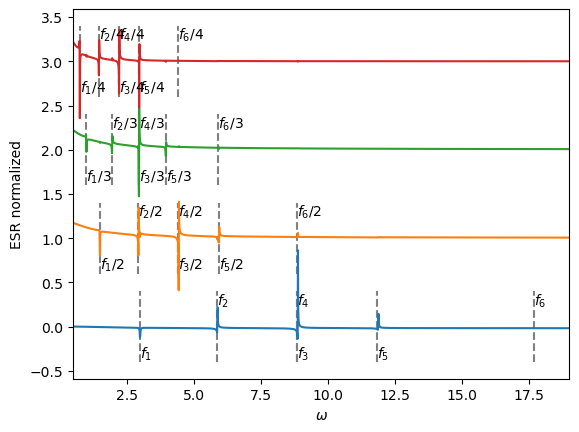

In [9]:
shift = 1

plt.vlines(resonant  , -.4+0*shift, .4+0*shift, 'gray', '--')
plt.vlines(resonant/2, -.4+1*shift, .4+1*shift, 'gray', '--')
plt.vlines(resonant/3, -.4+2*shift, .4+2*shift, 'gray', '--')
plt.vlines(resonant/4, -.4+3*shift, .4+3*shift, 'gray', '--')

plt.plot(frequencies, I1n+0*shift)
plt.plot(frequencies, I2n+1*shift)
plt.plot(frequencies, I3n+2*shift)
plt.plot(frequencies, I4n+3*shift)

plt.text(resonant[0],0*shift-.2,r'$f_1$', ha='left', va='top')
plt.text(resonant[1],0*shift+.2,r'$f_2$', ha='left', va='bottom')
plt.text(resonant[2],0*shift-.2,r'$f_3$', ha='left', va='top')
plt.text(resonant[3],0*shift+.2,r'$f_4$', ha='left', va='bottom')
plt.text(resonant[4],0*shift-.2,r'$f_5$', ha='left', va='top')
plt.text(resonant[5],0*shift+.2,r'$f_6$', ha='left', va='bottom')

plt.text(resonant[0]/2,1*shift-.2,r'$f_1/2$', ha='left', va='top')
plt.text(resonant[1]/2,1*shift+.2,r'$f_2/2$', ha='left', va='bottom')
plt.text(resonant[2]/2,1*shift-.2,r'$f_3/2$', ha='left', va='top')
plt.text(resonant[3]/2,1*shift+.2,r'$f_4/2$', ha='left', va='bottom')
plt.text(resonant[4]/2,1*shift-.2,r'$f_5/2$', ha='left', va='top')
plt.text(resonant[5]/2,1*shift+.2,r'$f_6/2$',ha='left', va='bottom')

plt.text(resonant[0]/3,2*shift-.2,r'$f_1/3$', ha='left', va='top')
plt.text(resonant[1]/3,2*shift+.2,r'$f_2/3$', ha='left', va='bottom')
plt.text(resonant[2]/3,2*shift-.2,r'$f_3/3$', ha='left', va='top')
plt.text(resonant[3]/3,2*shift+.2,r'$f_4/3$', ha='left', va='bottom')
plt.text(resonant[4]/3,2*shift-.2,r'$f_5/3$', ha='left', va='top')
plt.text(resonant[5]/3,2*shift+.2,r'$f_6/3$', ha='left', va='bottom')

plt.text(resonant[0]/4,3*shift-.2,r'$f_1/4$', ha='left', va='top')
plt.text(resonant[1]/4,3*shift+.2,r'$f_2/4$', ha='left', va='bottom')
plt.text(resonant[2]/4,3*shift-.2,r'$f_3/4$', ha='left', va='top')
plt.text(resonant[3]/4,3*shift+.2,r'$f_4/4$', ha='left', va='bottom')
plt.text(resonant[4]/4,3*shift-.2,r'$f_5/4$', ha='left', va='top')
plt.text(resonant[5]/4,3*shift+.2,r'$f_6/4$', ha='left', va='bottom')

plt.xlim(0.5,19)

plt.xlabel(r'$\omega$')
plt.ylabel(r'ESR normalized')

Note that we don't see any signal at $f_6$. This is because the second site has the same spin in neutral singlet states as in the charged states. Thus, there is now connection between $|g\rangle$ and $e\rangle$ through the charged states. 
We can fix this by either making the magnetic field different on the two sites, or making the exchange anisotropic. Both are likely the case in experiment; the magnetic field is inhomogeneous in space, and the exchange will be partly mediated by the surface  

In [10]:
Jexch_anisopt = np.array([3.,0.,0.])
Bext_2 = np.array([0.3,  0.,  0.1])
dot_two_field = PyESRSTM.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext_2]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch,1,0], ])
dot_anisop = PyESRSTM.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch_anisopt,1,0], ])

resonant_two_field = np.unique(np.abs(dot_two_field.Delta[:4,:4]))[1:]*units.Hartree/units.GHz
resonant_anisop = np.unique(np.abs(dot_anisop.Delta[:4,:4]))[1:]*units.Hartree/units.GHz

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


In [11]:
I1_two_field = PyESRSTM.ESR.ESR(Left, Right, dot_two_field, frequencies, NFL=1)[:,1]
I1_anisop = PyESRSTM.ESR.ESR(Left, Right, dot_anisop, frequencies, NFL=1)[:,1]

In [12]:
I1_two_field_n = I1_two_field - I1_two_field[0]
I1_anisop_n = I1_anisop - I1_anisop[0]

I1_two_field_n /= np.max(I1_two_field_n) - np.min(I1_two_field_n)
I1_anisop_n /= np.max(I1_anisop_n) - np.min(I1_anisop_n)

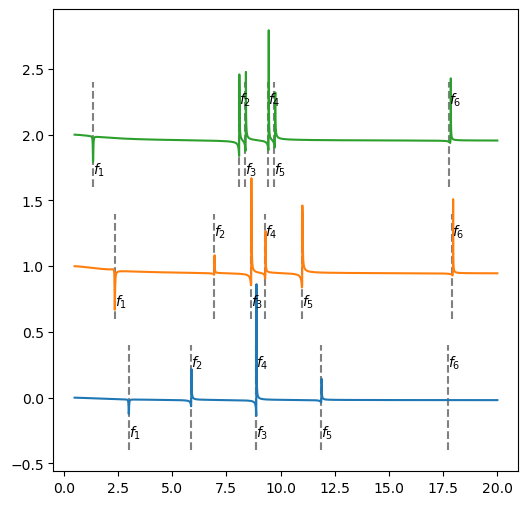

In [13]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax = [ax]

ax[0].vlines(resonant  , -.4+0*shift, .4+0*shift, 'gray', '--')
ax[0].vlines(resonant_two_field, -.4+1*shift, .4+1*shift, 'gray', '--')
ax[0].vlines(resonant_anisop, -.4+2*shift, .4+2*shift, 'gray', '--')

ax[0].plot(frequencies, I1n+0*shift)
ax[0].plot(frequencies, I1_two_field_n+1*shift)
ax[0].plot(frequencies, I1_anisop_n+2*shift)

ax[0].text(resonant[0],0*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant[1],0*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant[2],0*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant[3],0*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant[4],0*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant[5],0*shift+.2,r'$f_6$', ha='left', va='bottom')

ax[0].text(resonant_two_field[0],1*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant_two_field[1],1*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant_two_field[2],1*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant_two_field[3],1*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant_two_field[4],1*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant_two_field[5],1*shift+.2,r'$f_6$', ha='left', va='bottom')

ax[0].text(resonant_anisop[0],2*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant_anisop[1],2*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant_anisop[2],2*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant_anisop[3],2*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant_anisop[4],2*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant_anisop[5],2*shift+.2,r'$f_6$', ha='left', va='bottom')

plt.show()

## Trying to simpliffy things

I am trying to figure out if the level transition of the impurity  could be seperated as well as the Fourier components. Bellow I show how to remove states from a `QD`. Only the singly occupied levels 2,3 are removed if we want to remove the charged levels we would need to specify them. 

In [14]:
from copy import deepcopy
dot_red = deepcopy(dot)
dot_red.remove_states(np.array([2,3]))
print(dot_red.print_lamb())

0	4	0	0.98709 + i0.00000
0	4	1	-0.16018 + i0.00000
1	4	0	-0.11327 + i0.00000
1	4	1	-0.69798 + i0.00000
1	5	0	0.69798 + i0.00000
1	5	1	-0.11327 + i0.00000
2	0	0	-0.16018 + i0.00000
2	0	1	0.98709 + i0.00000
2	1	0	-0.69798 + i0.00000
2	1	1	-0.11327 + i0.00000
3	1	0	-0.11327 + i0.00000
3	1	1	0.69798 + i0.00000



/home/matyas/Programs/PyESRSTM/PyESRSTM/QD/QD.py:283: ComplexWarning: Casting complex values to real discards the imaginary part
  string += '{:.0f}\t{:.0f}\t{:.0f}\t{:.5f} + i{:.5f}\n'.format(*state[:3].astype(int), np.real(state[3]), np.imag(state[3]))


Next we calculate resonance considering some qd levels are mising

In [15]:
I1_red = np.empty((6,len(frequencies)))
k =0
for i in range(4):
    for j in range(i+1,4):
        dot_red = deepcopy(dot_two_field)
        dot_red.remove_states(np.array([i,j]))
        I1_red[k] = PyESRSTM.ESR.ESR(Left, Right, dot_red, frequencies, NFL=1)[:,1]
        k+=1

/tmp/ipykernel_330079/98858840.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  I1_red[k] = PyESRSTM.ESR.ESR(Left, Right, dot_red, frequencies, NFL=1)[:,1]


In [16]:
I1 = PyESRSTM.ESR.ESR(Left, Right, dot_two_field, frequencies, NFL=1)[:,1]

In [17]:
I1 -= I1[-1]
I1_red -= I1_red[:,-1:]

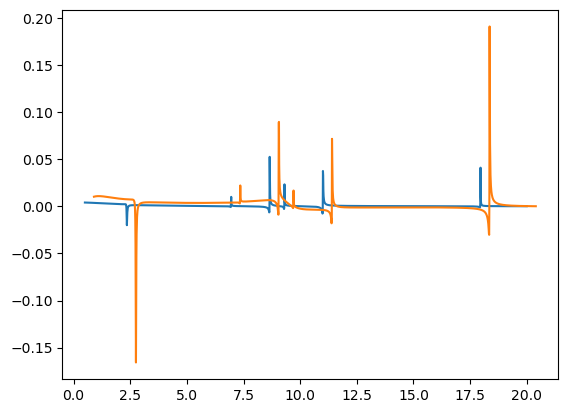

In [18]:
plt.plot(frequencies, I1)
plt.plot(frequencies+.4, np.sum(I1_red,axis=0))

This thing clearly does not work, impliying that the dynamics of one resonance is affected by the existance of other staes, which makes sense, but I don't undestand how this happesn fully. 